# <center> Data Science in Healthcare : Breast Cancer Detection <center/>
<center> <b>DLBDSME01<b/> - Model Engineering <center/>
<center> IU International University of Applied Sciences <center/>

## Objective :
Greetings, in this project, our goal is to help our local oncologists address the interpretability challenges of these systems by developing a transparent ML model capable of classifying tumors as Malignant or Benign while ensuring explainability in decision-making.

In this notebook, we aim to select the best model to serve as the core model for this project.

## Table of Contents
1. About the dataset
2. Exploratory Data Analysis
   * 2.1. The Target variable
   * 2.2. Features
3. Data Preparation
4. Modeling
   * 4.1. Models selection
   * 4.2. Splitting data
   * 4.3. Training, Testing, and Evaluation
   * 4.4. Model Tweaking
   * 4.5. Feature Importance
5. Summary

Start with importing the required libraries :

In [1]:
# Importing the required libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, Perceptron
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.exceptions import FitFailedWarning, ConvergenceWarning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
import matplotlib.gridspec as gridspec
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.base import clone
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import joblib


# Avoid unnecessary warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=FitFailedWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Basic style for the visualizations
sns.set_style('white')

### 1. About the dataset
The data we're operating on in this project is **Breast Cancer Wisconsin (Diagnostic)**, donated on *10/31/1995*, provided in .csv format available from [here](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic). **Each row in this dataset represents a single tumor sample from one patient**. Specifically, the data in a single row is the mathematical breakdown of a digitized image of a Fine Needle Aspirate (FNA) test—a clinical procedure where a small sample of cells is extracted from a breast mass. The algorithm that created this dataset looked at the cell nuclei in that image and calculated specific measurements to describe their size, shape, and texture.

#### The "Rule of 3" (How 10 traits become 30 features)

Instead of just 10 columns, the dataset has 30 numeric feature columns. This is because for every single clinical trait, the dataset records three different statistical calculations:

1. **Mean:** The average value of that trait across all the cells in the image.
2. **Standard Error (SE):** How much that trait varies among the cells in the sample.
3. **Worst (Largest):** The average of the three largest values found in the image. (This is highly useful because cancerous cells often exhibit extreme, irregular shapes).

#### The 10 Core Biological Traits

Every feature in this dataset is a variation (Mean, SE, or Worst) of these 10 core measurements of the cell nuclei:

1. **Radius:** The distance from the center of the nucleus to its outer edge.
2. **Texture:** The standard deviation of the grayscale values in the image. (Malignant cells often have a rougher, more irregular visual texture).
3. **Perimeter:** The total distance around the core of the nucleus.
4. **Area:** The total size of the nucleus. *(Note: Radius, Perimeter, and Area are the ones heavily correlated in your heatmap).*
5. **Smoothness:** Measures local variations in the radius lengths. It indicates if the edge of the nucleus is perfectly smooth or jagged.
6. **Compactness:** A mathematical ratio comparing the perimeter to the area ($Perimeter^2 / Area - 1.0$).
7. **Concavity:** The severity of "dents" or concave portions on the outline of the nucleus.
8. **Concave Points:** The actual *number* of those dents on the contour of the nucleus. Malignant cells are rarely perfectly round.
9. **Symmetry:** How symmetrical the cell nucleus is.
10. **Fractal Dimension:** A complex metric measuring the "coastline approximation." Essentially, it measures the complexity of the cell's boundary.

### The Final DataFrame Structure

When you put it all together, a single row in your Pandas DataFrame looks like this:

* `ID Number`: The patient/sample identifier (usually dropped before training).
* `Diagnosis`: The Target variable (`M` = Malignant, `B` = Benign).
* `radius_mean`, `texture_mean`, ... (10 features)
* `radius_se`, `texture_se`, ... (10 features)
* `radius_worst`, `texture_worst`, ... (10 features)

Let's start by loading the data

In [2]:
# Formulating the directory
path = Path.cwd().parent

# Loading the data
data = pd.read_csv(f'{path}/data/Data for Task 1.csv')

# Display a sample of the data
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Next, we head inspect the data for mixed data types, inconsistencies, or null values.

In [3]:
# Displaying the data's description
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

The result of the inspection was as follows :
* Data Completeness: There are 0 missing values across all 569 records
* Data Consistency: All 30 features (radius, texture, etc.) are stored as float64 (decimal numbers).
* Target Format: The diagnosis is currently a categorical "object" (B or M). We will need to encode this numerically later.

### 2. Exploratory Data Analysis
At this phase, we start to explore the data to gain insights into the distribution of the features and the target variable.


#### 2.1. The Target variable
The "diagnosis" variable is the the feature we're intending to predict at the end of our modelling.

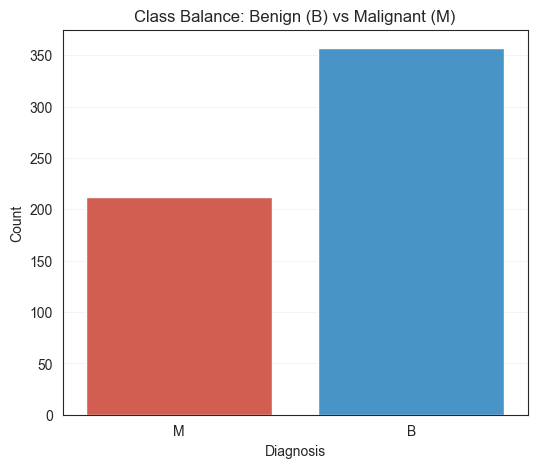

In [4]:
# Visualize the class balance
plt.figure(figsize=(6, 5))

# Create a countplot to visualize the class balance
sns.countplot(data=data, x='diagnosis', palette=['#e74c3c', '#3498db'])

# Add a title and axis labels
plt.title('Class Balance: Benign (B) vs Malignant (M)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

# Save the plot to a file
plt.savefig(f"{path}/assets/figures/Fig. 1 - Diagnosis countplot.png")

The dataset contains 62% benign tumors and 38% malignant tumors. This information is too valuable for the following aspects :
* While splitting the dataset into training and testing sets, this imbalance should be taken into consideration to avoid overfitting.
* The most important metric to evaluate the performance of the model is the **Recall** (Sensitivity).

#### 2.2. Features
As discussed in the first Chapter, we have 30 predicting variables. In the next violin plots, we explore the distribution of each feature per diagnosis.

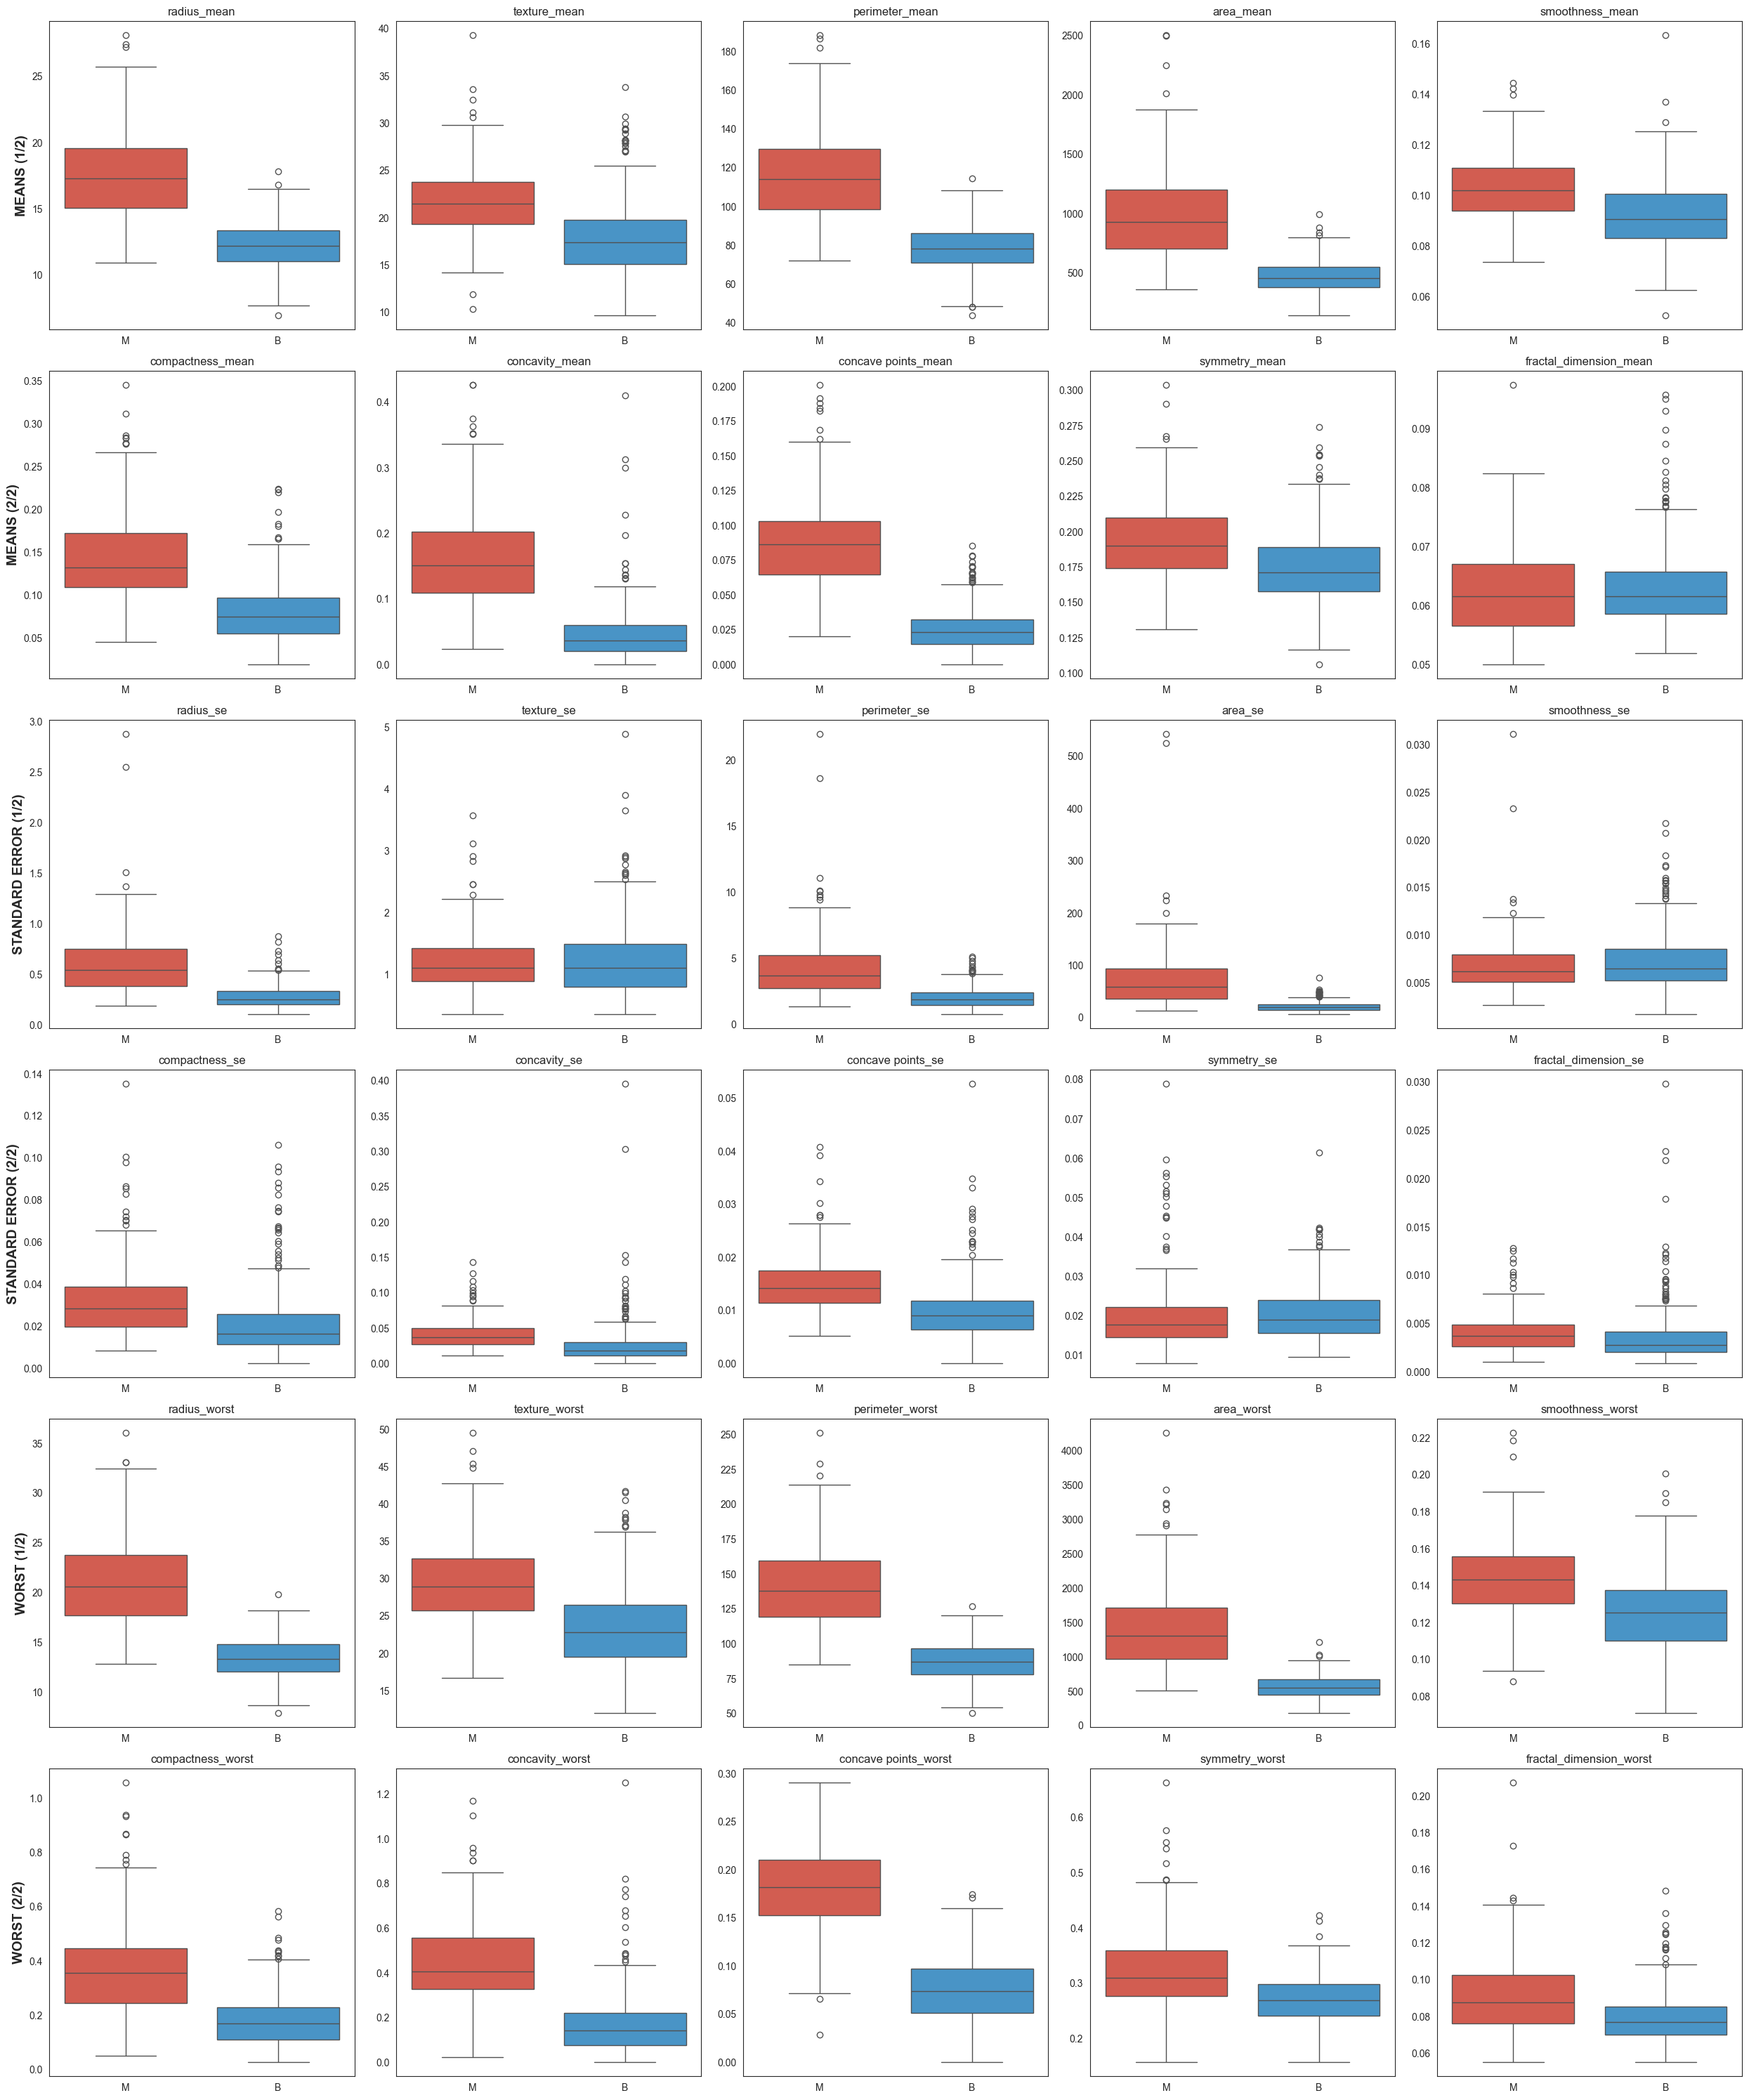

In [5]:
# Define the base features
base_features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave points', 'symmetry', 'fractal_dimension'
]

# Split into two groups for 2-row layout per category
group1 = base_features[:5]
group2 = base_features[5:]
categories = [
    ('_mean', 'MEANS'),
    ('_se', 'STANDARD ERROR'),
    ('_worst', 'WORST')
]

# Total rows = 3 categories * 2 rows per category = 6 rows
fig, axes = plt.subplots(6, 5, figsize=(25, 30))
current_plot_row = 0

# Run the loop
for suffix, cat_name in categories:

    # Plot first 5 features (Row 1 of category)
    for col, feat in enumerate(group1):
        ax = axes[current_plot_row, col]
        sns.boxplot(data=data, x='diagnosis', y=f"{feat}{suffix}", ax=ax, palette=['#e74c3c', '#3498db'])
        ax.set_title(f"{feat}{suffix}", fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('')
        if col == 0:
            ax.set_ylabel(f"{cat_name} (1/2)", fontsize=14, fontweight='bold')

    current_plot_row += 1

    # Plot next 5 features (Row 2 of category)
    for col, feat in enumerate(group2):
        ax = axes[current_plot_row, col]
        sns.boxplot(data=data, x='diagnosis', y=f"{feat}{suffix}", ax=ax, palette=['#e74c3c', '#3498db'])
        ax.set_title(f"{feat}{suffix}", fontsize=12)
        ax.set_xlabel('')
        ax.set_ylabel('')
        if col == 0:
            ax.set_ylabel(f"{cat_name} (2/2)", fontsize=14, fontweight='bold')

    current_plot_row += 1


# Save the plot to a file
plt.tight_layout()
plt.savefig(f"{path}/assets/figures/Fig. 2 - Features distribution by dignosis.png")

Based on these visualizations, we can instantly tell that **Benign cells are more uniformly distributed than malignant cells**.
Furthermore, we can draw the following conclusions :


**1. Chaos translates in Biologically to Malignancy**

The extreme variance observed in the malignant class is not a data collection error; it is the mathematical manifestation of cellular chaos. By preserving these outliers and using a RobustScaler, our model will learn to recognize this biological volatility as a primary predictor of cancer, rather than treating it as statistical noise.

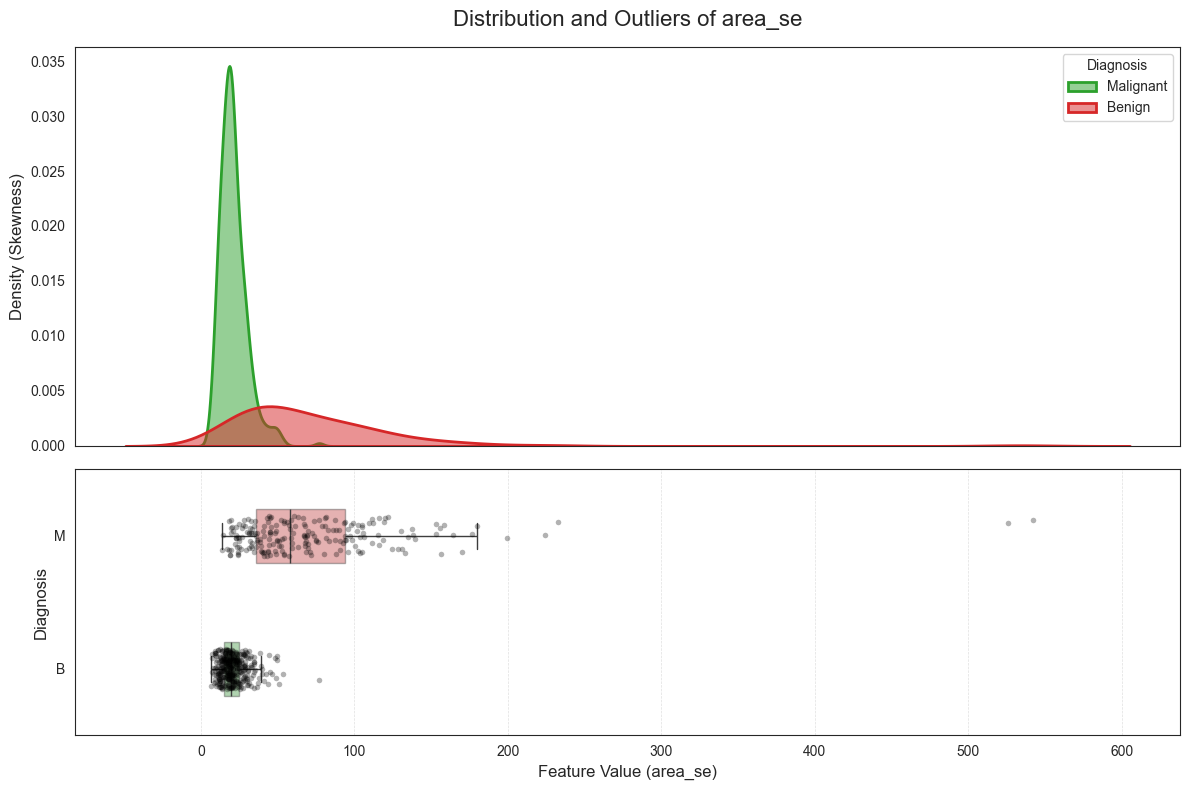

In [6]:
# Choose the single most skewed/interesting feature to highlight
feature_to_plot = 'area_se'

# Create a figure with 2 subplots stacked vertically, sharing the X-axis
fig, (ax_kde, ax_box) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": (.6, .4)} # KDE gets more space
)

# --- 1. The "Cloud" (Density Plot to show Skewness) ---
sns.kdeplot(
    data=data, x=feature_to_plot, hue='diagnosis',
    fill=True, alpha=0.5, linewidth=2, ax=ax_kde,
    palette={'B': '#2ca02c', 'M': '#d62728'}
)
ax_kde.set_title(f'Distribution and Outliers of {feature_to_plot}', fontsize=16, pad=15)
ax_kde.set_ylabel('Density (Skewness)', fontsize=12)
ax_kde.legend(title='Diagnosis', labels=['Malignant', 'Benign']) # Adjust based on your hue order

# --- 2. The "Umbrella & Rain" (Boxplot + Strip Plot for Outliers) ---
sns.boxplot(
    data=data, x=feature_to_plot, y='diagnosis',
    width=0.4, fliersize=0, # Hide default boxplot outliers so they don't double-print
    ax=ax_box, palette={'B': '#2ca02c', 'M': '#d62728'},
    boxprops=dict(alpha=0.4) # Make the boxes slightly transparent
)

# Overlay the actual data points to show the severity of the outliers
sns.stripplot(
    data=data, x=feature_to_plot, y='diagnosis',
    size=4, color="black", alpha=0.3, jitter=0.15, ax=ax_box
)

# Add labels
ax_box.set_xlabel(f'Feature Value ({feature_to_plot})', fontsize=12)
ax_box.set_ylabel('Diagnosis', fontsize=12)
ax_box.grid(axis='x', linestyle='--', alpha=0.6)

# Save the plot to a file
plt.tight_layout()
plt.savefig(f"{path}/assets/figures/Fig. 3 - Feature\'s overlap.png")

# Display the plot
plt.show()

**2. Features Pruning**

While features including *radius_mean*, *perimeter_mean*, and *area_mean* exhibit clear linear separability, validating the use of simple, highly interpretable classification models. Other features like *texture_se* and *smoothness_se* fail to provide information about the diagnosis.

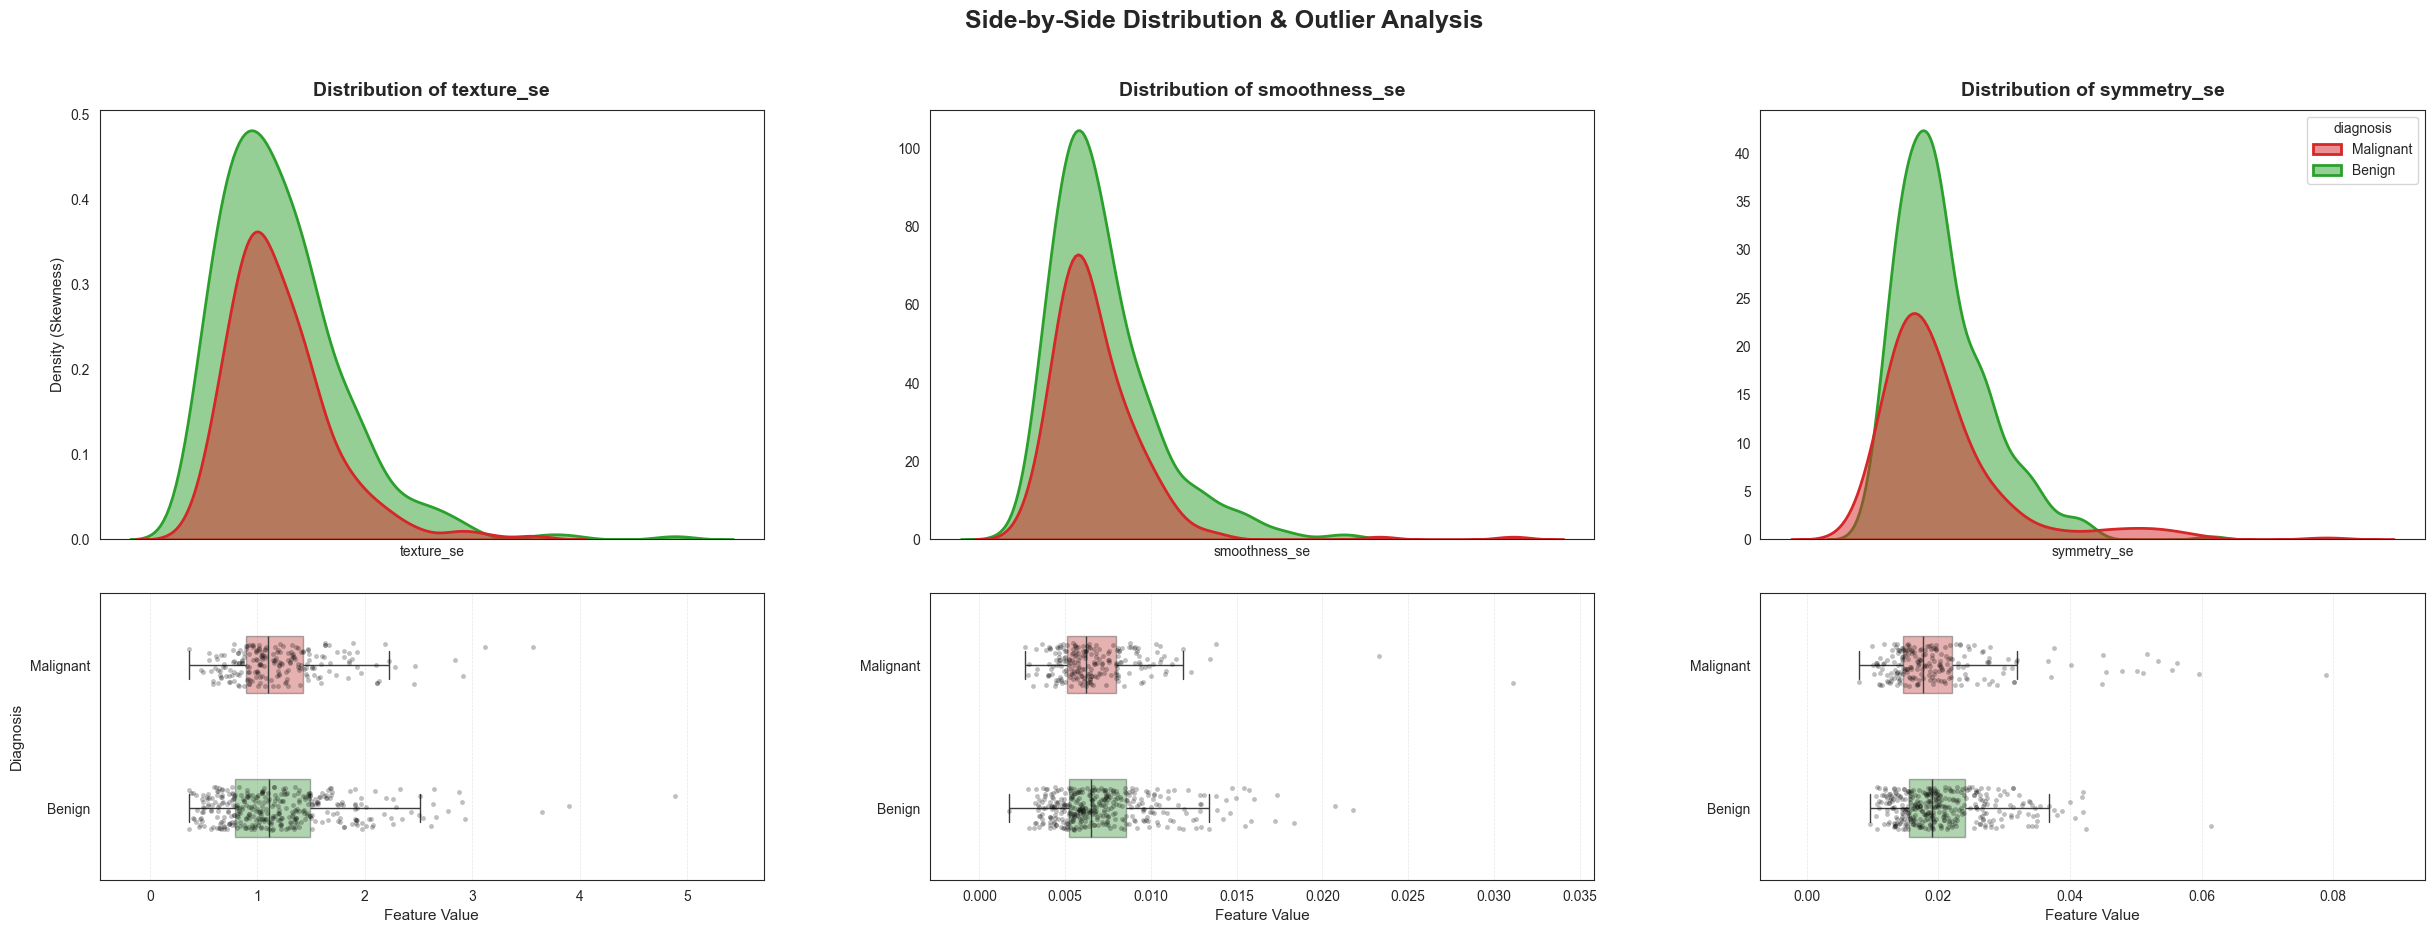

In [7]:
# Define the list of features you want to plot
features_to_plot = ['texture_se', 'smoothness_se', 'symmetry_se']

# Temporarily map the diagnosis column for clean legend and axis titles
data_mapped = data.copy()
data_mapped['diagnosis'] = data_mapped['diagnosis'].map({'M': 'Malignant', 'B': 'Benign'})

# Create a master figure layout (2 rows for KDE/Box, 3 columns for the 3 features)
fig = plt.figure(figsize=(30, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[0.6, 0.4], hspace=0.15, wspace=0.25)

# Generate the subplots dynamically inside the grid
for i, feature in enumerate(features_to_plot):
    # Allocate top and bottom axes for the current column
    ax_kde = fig.add_subplot(gs[0, i])
    ax_box = fig.add_subplot(gs[1, i], sharex=ax_kde) # sharex links the X-axes

    # Density Plot to show Skewness
    sns.kdeplot(
        data=data_mapped, x=feature, hue='diagnosis',
        hue_order=['Malignant', 'Benign'],
        fill=True, alpha=0.5, linewidth=2, ax=ax_kde,
        palette={'Benign': '#2ca02c', 'Malignant': '#d62728'},
        legend=(i == 2)
    )

    # Adding title, parameters and and labels
    ax_kde.set_title(f'Distribution of {feature}', fontsize=14, pad=10, fontweight='bold')
    ax_kde.set_ylabel('Density (Skewness)' if i == 0 else '', fontsize=11) # Y-label only on leftmost plot
    ax_kde.tick_params(labelbottom=False) # Hide X-ticks on the top row since they share X

    # Boxplot + Strip Plot for Outliers
    sns.boxplot(
        data=data_mapped, x=feature, y='diagnosis',
        order=['Malignant', 'Benign'],
        width=0.4, fliersize=0,
        ax=ax_box, palette={'Benign': '#2ca02c', 'Malignant': '#d62728'},
        boxprops=dict(alpha=0.4)
    )

    # Overlay the actual data points
    sns.stripplot(
        data=data_mapped, x=feature, y='diagnosis',
        order=['Malignant', 'Benign'],
        size=3.5, color="black", alpha=0.25, jitter=0.15, ax=ax_box
    )

    # Adding labels
    ax_box.set_xlabel(f'Feature Value', fontsize=11)
    ax_box.set_ylabel('Diagnosis' if i == 0 else '', fontsize=11) # Y-label only on leftmost plot
    ax_box.grid(axis='x', linestyle='--', alpha=0.5)

# Add a grand title for the entire dashboard layout
fig.suptitle('Side-by-Side Distribution & Outlier Analysis', fontsize=18, weight='bold', y=0.98)

# Save the plot to a file
plt.savefig(f"{path}/assets/figures/Fig. 4 - Features distribution and outliers.png")

# Clean-up layout
plt.show()

**3. Features Correlation**

To minimize model complexity, feature selection was limited strictly to uncorrelated variables.

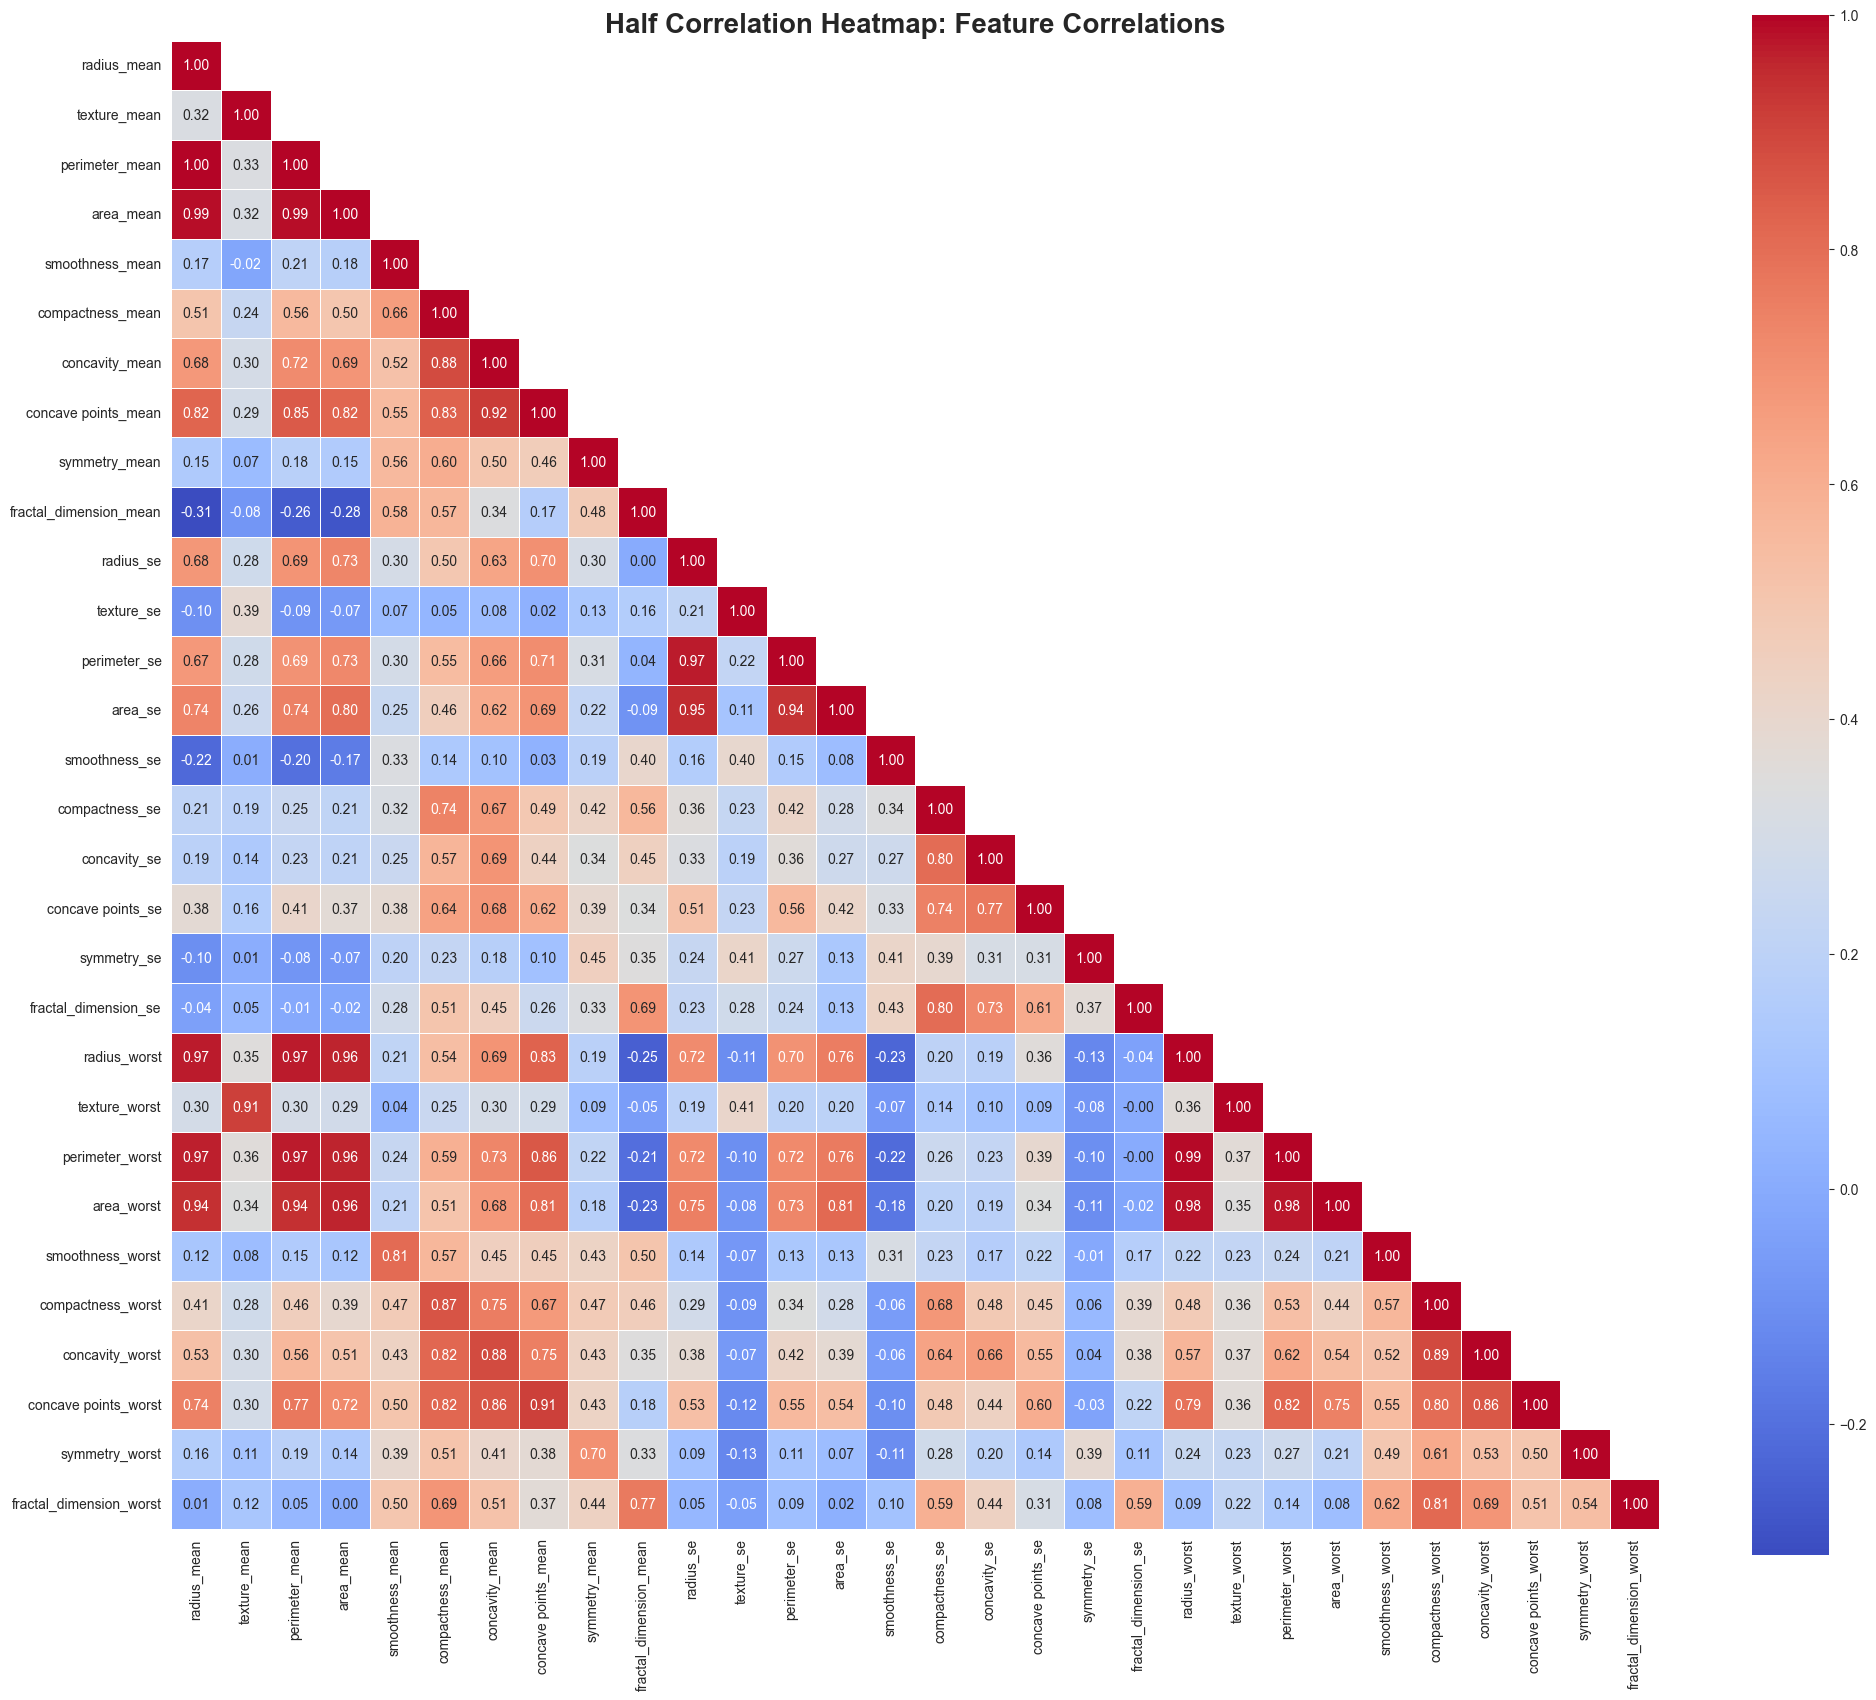

In [8]:
# Drop non-predictive and target columns
df_corr = data.drop(columns=['id', 'diagnosis'])

# Correlation matrix
corr_matrix = df_corr.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)).T

# Plot the heatmap
plt.figure(figsize=(24, 20))
sns.heatmap(
    corr_matrix,
    mask=~mask,              # hides upper triangle
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

# Add title
plt.title(
    'Half Correlation Heatmap: Feature Correlations',
    fontsize=20,
    fontweight='bold'
)

# Save figure
plt.savefig(f"{path}/assets/figures/Fig. 5 - Half Correlation Heatmap.png", bbox_inches='tight')
plt.show()

In [9]:
# Highlight highly correlated feature pairs
high_corr = corr_matrix.abs().unstack()
high_corr = high_corr.sort_values(ascending=False)

# Remove self-correlations and duplicate pairs
redundant_pairs = high_corr[(high_corr > 0.9) & (high_corr < 1.0)].drop_duplicates()

# Print pairs
redundant_pairs

perimeter_mean       radius_mean             0.997855
radius_worst         perimeter_worst         0.993708
radius_mean          area_mean               0.987357
area_mean            perimeter_mean          0.986507
area_worst           radius_worst            0.984015
                     perimeter_worst         0.977578
radius_se            perimeter_se            0.972794
perimeter_worst      perimeter_mean          0.970387
radius_mean          radius_worst            0.969539
radius_worst         perimeter_mean          0.969476
perimeter_worst      radius_mean             0.965137
area_mean            radius_worst            0.962746
                     area_worst              0.959213
perimeter_worst      area_mean               0.959120
radius_se            area_se                 0.951830
area_worst           perimeter_mean          0.941550
                     radius_mean             0.941082
area_se              perimeter_se            0.937655
concave points_mean  concavi

### 3. Data Preparation
Subsequently, we move toward applying the techniques discussed in the previous chapters to the data. Starting by transforming the data and encoding the target variable.

In [10]:
# Encode the target variable
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

Then, we proceed to removing correlated features and feature with no predictive power from the dataset. For versioning purposes, the pre processed data ought to be saved.

In [11]:
# Dataset v1.0.0
data_v1_0_0 = data.copy()

# Dataset v1.0.1 - Drop non-informative features
data_v1_1_0 = data_v1_0_0.drop(columns=['texture_se', 'smoothness_se', 'symmetry_se'])

# Dataset v1.0.2 - Drop highly correlated features at .95 threshold 
data_v1_2_0 = data_v1_1_0.drop(columns=['area_mean', 'area_worst', 'area_se', 'radius_worst', 'perimeter_se'])

# Dataset v1.0.3 - Drop highly correlated features at .99 threshold
data_v1_3_0 = data_v1_2_0.drop(columns=['perimeter_mean', 'perimeter_worst'])

# Save the datasets
data_v1_0_0.to_csv(f"{path}/data/data_v1.0.0.csv", index=False)
data_v1_1_0.to_csv(f"{path}/data/data_v1.1.0.csv", index=False)
data_v1_2_0.to_csv(f"{path}/data/data_v1.2.0.csv", index=False)
data_v1_3_0.to_csv(f"{path}/data/data_v1.3.0.csv", index=False)

### 4. Modelling
In this phase, we will be training a bunch of models on the data with the final purpose of cross examining their metrics and their interpretability to choose the main model to be used.

#### 4.1. Models Selection
In this section, we will define the models we want to use. 


In [12]:
# The models are stored as tuples: (Name, Interpretability, Model Object)
models_list = [
    # --- GOOD INTERPRETABILITY (White-Box, Human-Readable Logic) ---
    ("LogisticRegression", "Good", LogisticRegression(random_state=42, max_iter=1000)),
    ("DecisionTree_Gini", "Good", DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)),
    ("DecisionTree_Entropy", "Good", DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)),
    ("LogisticRegression_L2", "Good", LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")),
    ("GaussianNB", "Good", GaussianNB()), # Moved from Medium (Transparent probabilistic math)
    ("ExtraTreeClassifier", "Good", ExtraTreeClassifier(max_depth=5, random_state=42)), # Moved from Bad (Single shallow tree is easily plotted)

    # --- MEDIUM INTERPRETABILITY (Traceable logic, but slightly more complex) ---
    ("Perceptron", "Medium", Perceptron(random_state=42)),
    ("RidgeClassifier", "Medium", RidgeClassifier(random_state=42)),
    ("LinearDiscriminantAnalysis", "Medium", LinearDiscriminantAnalysis()),
    ("KNeighbors_K3", "Medium", KNeighborsClassifier(n_neighbors=3)), # Interpretable by example, not by global feature importance
    ("KNeighbors_K7", "Medium", KNeighborsClassifier(n_neighbors=7)),
    ("SVC_Linear", "Medium", SVC(kernel="linear", random_state=42)), # Moved from Bad (Has clear linear weights)
    ("LinearSVC", "Medium", LinearSVC(max_iter=5000, random_state=42)), # Moved from Bad (Has clear linear weights)
    ("SGDClassifier", "Medium", SGDClassifier(random_state=42)), # Moved from Bad (Linear model, easily inspected weights)

    # --- BAD INTERPRETABILITY (Black-Box / Complex Mathematical Ensembles / Kernel Tricks) ---
    ("RandomForest", "Bad", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("ExtraTrees", "Bad", ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ("BaggingClassifier", "Bad", BaggingClassifier(random_state=42)),
    ("AdaBoost", "Bad", AdaBoostClassifier(random_state=42)),
    ("GradientBoosting", "Bad", GradientBoostingClassifier(random_state=42)),
    ("HistGradientBoosting", "Bad", HistGradientBoostingClassifier(random_state=42)),
    ("SVC_RBF", "Bad", SVC(kernel="rbf", random_state=42)), # Infinite dimensional kernel trick
    ("SVC_Poly", "Bad", SVC(kernel="poly", degree=3, random_state=42)), # Complex polynomial transformations
    ("QuadraticDiscriminantAnalysis", "Bad", QuadraticDiscriminantAnalysis()) # Non-linear, complex boundary
]

#### 4.2. Splitting the Data
Then we proceed to split the data into training and testing sets. Before that, data preparation covered the most important work of the data. The last touch needed is limited to the use of a scaler right before the split to avoid *Data Leakage*.

*Note*:
> **Data Leakage** occurs when information from outside the training dataset is accidentally used to train a machine learning model, artificially inflating its performance.

> To prevent this, **Feature Scaling (StandardScaler)** is strictly performed *after* the train-test split. The scaler is initialized and fit solely on the training partition (`X_train`) to compute the feature means ($\mu$) and standard deviations ($\sigma$). The test partition (`X_test`) is treated as entirely unseen data and is transformed using those pre-computed training parameters. This architectural choice ensures that the test set remains untainted and provides an unbiased evaluation of the models' real-world generalization capability.

#### 4.3. Training, Testing, and Evaluation
We prioritize interpretability first, then recall within the same interpretability tier.

In [13]:
# Initiate Variables & Set up Paths
results = []
failed_models = []
trained_models = {}

# Mock placeholders for your environment data dataframes and model list
datasets = {
    "1.0.0": data_v1_0_0,
    "1.1.0": data_v1_1_0,
    "1.2.0": data_v1_2_0,
    "1.3.0": data_v1_3_0,
}

# Define Dataset Splits & Fit Scalers
dataset_splits = {}

# Start the loop
for dataset_version, dataset_df in datasets.items():
    # Prepare features and targets
    X = dataset_df.drop(columns=['diagnosis'])
    y = dataset_df['diagnosis']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=123,
        stratify=y
    )

    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save the splits along with the scaler object itself to prevent inference mismatches later
    dataset_splits[dataset_version] = {
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }

In [14]:
# Main Training and Evaluation Loop
for dataset_version, split in dataset_splits.items():

    # Load data splits and associated scaler
    dataset_name = f"data_v{dataset_version}"
    X_train_scaled = split["X_train_scaled"]
    X_test_scaled = split["X_test_scaled"]
    y_train = split["y_train"]
    y_test = split["y_test"]

    # Train each model on the current dataset
    for i, (name, interpretability, model) in enumerate(models_list, start=1):
        try:
            active_model = clone(model)

            # Fit model
            active_model.fit(X_train_scaled, y_train)
            trained_models[(dataset_version, name)] = active_model

            # Generate evaluation predictions
            y_pred = active_model.predict(X_test_scaled)
            y_proba = active_model.predict_proba(X_test_scaled)[:, 1] if hasattr(active_model, "predict_proba") else None

            # Compute classification metrics
            metrics = {
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred, zero_division=0),
                "F1_Score": f1_score(y_test, y_pred, zero_division=0),
                "ROC_AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
            }

            # Save execution context
            results.append({
                "model_name": name,
                "interpretability": interpretability,
                "dataset_version": dataset_version,
                **metrics,
            })

        except Exception as exc:
            failed_models.append({
                "model_name": name,
                "interpretability": interpretability,
                "dataset_version": dataset_version,
                "error": str(exc),
            })

In [15]:
try :

    # Construct the dataframe
    results_df = pd.DataFrame(results)
    interpretability_priority = {"Good": 2, "Medium": 1, "Bad": 0}
    results_df["interpretability_score"] = results_df["interpretability"].map(interpretability_priority)

    # Sort results by interpretability tier, prioritizing balanced F1 performance over raw metrics
    results_df = results_df.sort_values(
        by=["interpretability_score", "F1_Score", "Recall", "Accuracy"],
        ascending=False,
    ).reset_index(drop=True)

# Display the results
finally:
    display(results_df)
    display(pd.DataFrame(failed_models))

# Save the metrics
results_df.to_csv(f"{path}/assets/metrics/models_evaluations.csv", index=False)

,model_name,interpretability,dataset_version,Accuracy,Precision,Recall,F1_Score,ROC_AUC,interpretability_score
0,LogisticRegression,Good,1.0.0,0.973684,0.953488,0.976190,0.964706,0.987434,2
1,LogisticRegression,Good,1.1.0,0.973684,0.953488,0.976190,0.964706,0.988426,2
2,LogisticRegression_L2,Good,1.0.0,0.956140,0.911111,0.976190,0.942529,0.987103,2
3,LogisticRegression_L2,Good,1.1.0,0.956140,0.911111,0.976190,0.942529,0.988426,2
4,LogisticRegression,Good,1.2.0,0.956140,0.911111,0.976190,0.942529,0.988095,2
...,...,...,...,...,...,...,...,...,...
84,QuadraticDiscriminantAnalysis,Bad,1.3.0,0.912281,0.833333,0.952381,0.888889,0.987434,0
85,SVC_Poly,Bad,1.1.0,0.921053,1.000000,0.785714,0.880000,NaN,0
86,SVC_Poly,Bad,1.2.0,0.921053,1.000000,0.785714,0.880000,NaN,0
87,SVC_Poly,Bad,1.0.0,0.912281,1.000000,0.761905,0.864865,NaN,0


,model_name,interpretability,dataset_version,error
0,QuadraticDiscriminantAnalysis,Bad,1.0.0,The covariance matrix of class 0 is not full r...
1,QuadraticDiscriminantAnalysis,Bad,1.1.0,The covariance matrix of class 0 is not full r...
2,QuadraticDiscriminantAnalysis,Bad,1.2.0,The covariance matrix of class 0 is not full r...


AttributeError: 'list' object has no attribute 'to_csv'

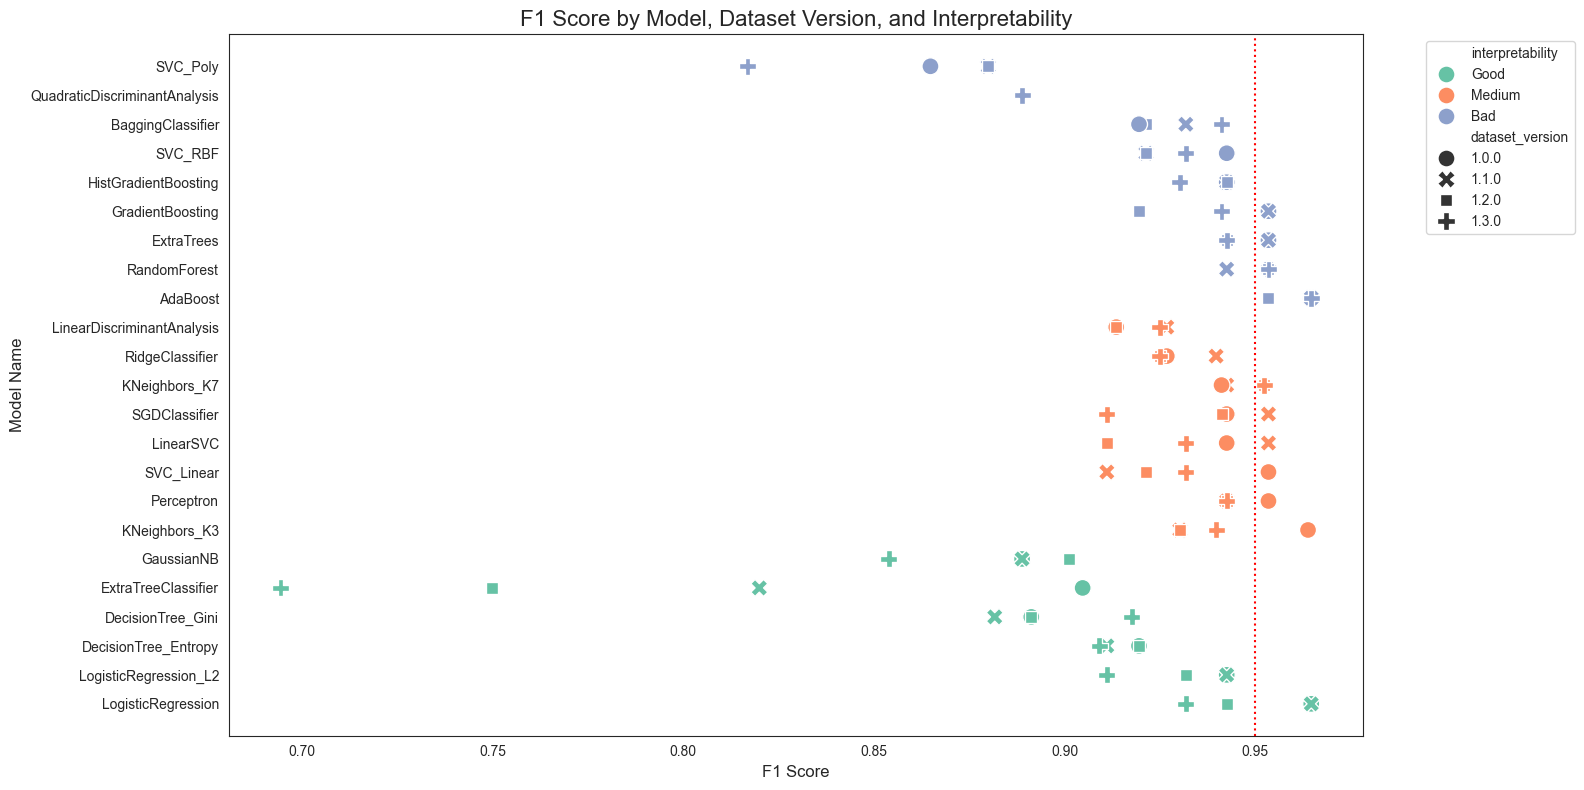

In [17]:
# Define the main figure
plt.figure(figsize=(16, 8))

# Create the scatter plot
sns.scatterplot(
    data=results_df,
    x='F1_Score',
    y='model_name',
    hue='interpretability',      # Color represents Interpretability
    style='dataset_version',     # Shape represents Dataset Version
    s=150,
    palette='Set2',              # A good palette for categorical data
)

# Add the title and labels
plt.title('F1 Score by Model, Dataset Version, and Interpretability', fontsize=16)
plt.ylabel('Model Name', fontsize=12)
plt.xlabel('F1 Score', fontsize=12)

# Invert axis
plt.gca().invert_yaxis()

# Place the combined legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the threshold
plt.axvline(x=0.95, color='red', linestyle=':')

# Save the figure
plt.savefig(f"{path}/assets/figures/Fig. 6 - F1 Score by Model, Dataset Version, and Interpretability.png", bbox_inches='tight')

# Display the figure
plt.tight_layout()
plt.show()

Despite our efforts to simplify the task by removing analytically irrelevant elements, the models successfully managed the collinearity and feature interactions found in the initial two dataset versions. Consequently, we will continue using dataset version 1.0.0 to further investigate models with an F1 Score exceeding 0.95

In [18]:
# Filter the data
evaluation_df = results_df[(results_df["dataset_version"] == "1.0.0") & (results_df["F1_Score"] >= 0.95)].drop(columns=["interpretability_score", "interpretability_score"])

# Save the shortlist
evaluation_df.to_csv(f"{path}/assets/metrics/models_shortlist.csv", index=False)

# Display the dataset
evaluation_df

,model_name,interpretability,dataset_version,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,LogisticRegression,Good,1.0.0,0.973684,0.953488,0.976190,0.964706,0.987434
24,KNeighbors_K3,Medium,1.0.0,0.973684,0.975610,0.952381,0.963855,0.984623
25,Perceptron,Medium,1.0.0,0.964912,0.931818,0.976190,0.953488,NaN
26,SVC_Linear,Medium,1.0.0,0.964912,0.931818,0.976190,0.953488,NaN
56,AdaBoost,Bad,1.0.0,0.973684,0.953488,0.976190,0.964706,0.991402
59,RandomForest,Bad,1.0.0,0.964912,0.931818,0.976190,0.953488,0.987599
60,ExtraTrees,Bad,1.0.0,0.964912,0.931818,0.976190,0.953488,0.987599
61,GradientBoosting,Bad,1.0.0,0.964912,0.931818,0.976190,0.953488,0.987103


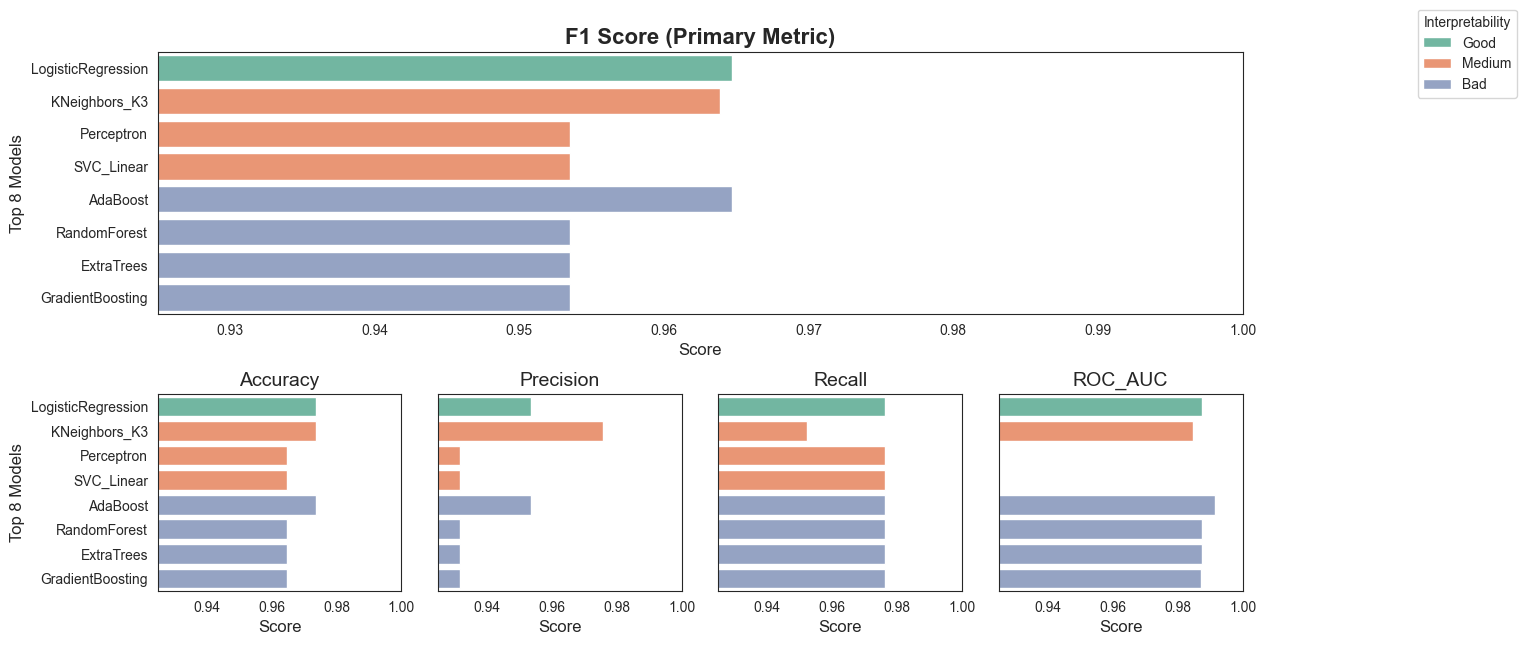

In [22]:
# Create a figure and define the grid dimensions (2 rows, 4 columns)
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(2, 4, figure=fig, height_ratios=[1, 0.75], hspace=0.35, wspace=0.15)


# The top plot : F1 Score
ax_top = fig.add_subplot(gs[0, :])
sns.barplot(
    data=evaluation_df,
    x='F1_Score',
    y='model_name',
    hue='interpretability',
    palette='Set2',
    ax=ax_top,
    dodge=False
)

# Added title and labels
ax_top.set_title('F1 Score (Primary Metric)', fontsize=16, fontweight='bold')
ax_top.set_xlabel('Score', fontsize=12)
ax_top.set_ylabel('Top 8 Models', fontsize=12)
ax_top.set_xlim(0.925, 1.0)
if ax_top.get_legend() is not None:
    ax_top.legend_.remove()

# The remaining plots
bottom_metrics = ['Accuracy', 'Precision', 'Recall', 'ROC_AUC']
for i, metric in enumerate(bottom_metrics):
    ax = fig.add_subplot(gs[1, i])

    sns.barplot(
        data=evaluation_df,
        x=metric,
        y='model_name',
        hue='interpretability',
        palette='Set2',
        ax=ax,
        dodge=False
    )

    ax.set_title(f'{metric}', fontsize=14)
    ax.set_xlabel('Score', fontsize=12)
    ax.set_xlim(0.925, 1.0)

    # Only show Y-axis labels on the leftmost subplot to avoid clutter
    if i == 0:
        ax.set_ylabel('Top 8 Models', fontsize=12)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([]) # Hide the model names on inner plots

    if ax.get_legend() is not None:
        ax.legend_.remove()

# Unified the legend
handles, labels = ax_top.get_legend_handles_labels()
fig.legend(handles, labels, title='Interpretability', bbox_to_anchor=(1.02, 0.95), loc='upper left')

# Save the figure
plt.savefig(f"{path}/assets/figures/Fig. 7 - Shortlisted Models Evaluation.png")
plt.show()

Based on our evaluation results:
* Three models achieved an F1 score greater than 96%.
* Two of those models also exceeded a 96% recall rate.
* Logistic Regression was the only model to deliver superior interpretability.

As a result, Logistic Regression has been selected as the project's primary and highest-performing model.

#### 4.4. Model Tweaking
Now that we have chosen the best model, we will focus on optimizing its hyperparameters to maximize predictive accuracy and improve our final evaluation metrics

In [23]:
# Range of splits for K-Fold
splits_range = range(2, 21)

# List to hold the scores
all_scores = []

# Loop over each number of splits
for n_splits in splits_range:

    # Define the KFold cross-validator
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Calculate cross-validated scores
    cv_scores = cross_val_score(
        Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
            ]),
        dataset_splits['1.0.0']['X_train_scaled'],
        dataset_splits['1.0.0']['y_train'],
        cv=kf,
        scoring='accuracy'
    )

    # Store the mean of the scores for the current n_splits configuration
    all_scores.append({
        'n_split': n_splits,
        'model': "Logistic Regression",
        'score_accuracy': cv_scores.mean()
    })

# Convert the list of scores to a DataFrame
df_scores = pd.DataFrame(all_scores)

# Use pivot_table to reshape the DataFrame
df_pivoted = df_scores.pivot_table(index='n_split', columns='model', values='score_accuracy')

# Print the reshaped DataFrame
df_pivoted

model,Logistic Regression
n_split,
2,0.969211
3,0.975834
4,0.978012
5,0.978022
6,0.980175
7,0.975824
8,0.977992
9,0.978039
10,0.978068


In [23]:
# Define a pipeline that includes scaling and the logistic regression model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42)) # max_iter moved to param_grid
])

# Define the parameter grid for Logistic Regression
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__tol': [1e-5, 1e-4, 1e-3, 1e-2],
    'logreg__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'logreg__penalty': ['l2', 'l1', None],
    'logreg__max_iter': [100, 200, 300, 1000],
    'logreg__class_weight': [None, 'balanced'],
}

# Define the KFold cross-validator
kf = KFold(n_splits=16, shuffle=True, random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=kf,
    scoring='accuracy',
    error_score=np.nan,
    verbose=1,
    n_jobs=-1
)

# Fit GridSearchCV (Assuming X and y are already defined in your environment)
grid_search.fit(dataset_splits['1.0.0']['X_train_scaled'], dataset_splits['1.0.0']['y_train'])

# Best parameters and best score
print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Fitting 16 folds for each of 2880 candidates, totalling 46080 fits

Best parameters found:
{'logreg__C': 0.1, 'logreg__class_weight': None, 'logreg__max_iter': 100, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear', 'logreg__tol': 1e-05}
Best cross-validation accuracy: 0.9846


In [24]:
# Set up the Logistic Regression model directly with the best parameters
best_model = LogisticRegression(
    C=0.1,
    class_weight=None,
    max_iter=100,
    penalty='l2',
    solver='saga',
    tol=1e-03,
    random_state=42
)

# Fit the model to the already scaled training set
best_model.fit(dataset_splits['1.0.0']['X_train_scaled'], dataset_splits['1.0.0']['y_train'])

# Evaluate score on the scaled test set
best_model.score(dataset_splits['1.0.0']['X_test_scaled'], dataset_splits['1.0.0']['y_test'])

0.9824561403508771

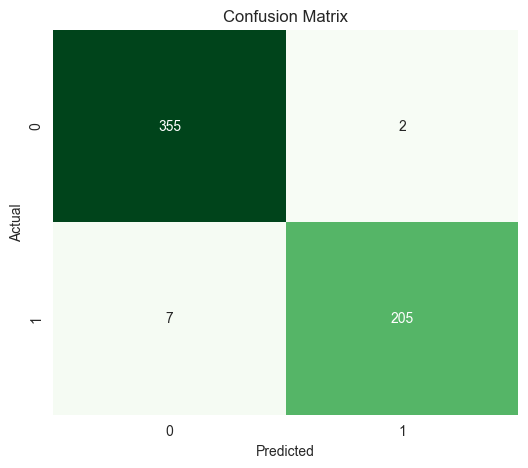

              precision    recall  f1-score   support

      Benign       0.98      0.99      0.99       357
   Malignant       0.99      0.97      0.98       212

    accuracy                           0.98       569
   macro avg       0.99      0.98      0.98       569
weighted avg       0.98      0.98      0.98       569



In [31]:
# Prepare features and targets
X = data_v1_0_0.drop(columns=['diagnosis'])
y = data_v1_0_0['diagnosis']

# Scale data
scaler = StandardScaler()
X_all = scaler.fit_transform(X)
y_all_pred = best_model.predict(X_all)

# Construct the confusion Matrix
cm_all = confusion_matrix(y, y_all_pred)
plt.figure(figsize=(6, 5))

# Platting the matrix
sns.heatmap(cm_all, annot=True, fmt="d", cmap="Greens", cbar=False)

# Added Title and Labels
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

# Save the plot
plt.savefig(f"{path}/assets/figures/Fig. 8 - Confusion Matrix.png")
plt.show()

# Print the classification report
print(classification_report(y, y_all_pred, target_names=["Benign", "Malignant"]))

In [32]:
# Create the filename with the current date
filename = f'{path}/models/main_model_v1.joblib'

# Save the model to a file
joblib.dump(best_model, filename)

['D:\\Projects_Portfolio\\Project - Breast Cancer Detection/models/main_model_v1.joblib']

### 5. Summary

In this notebook, we successfully trained and evaluated several models across different versions of the dataset. After rigorous testing, we selected **Logistic Regression** as our primary model due to its strong performance, and we further optimized it by tweaking its hyperparameters.

This concludes the first phase of the project. In the next phase, we will transition to a production environment and deploy the model for active use by our oncologists.

## Author
<a href="https://www.linkedin.com/in/ab0858s/">Abdelali BARIR</a> is a former veteran in the Moroccan's Royal Armed Forces, and a self-taught python programmer. Currently enrolled in B.Sc. Data Science in __IU International University of Applied Sciences__.

## Change Log

| Date         | Version   | Changed By       | Change Description        |
|--------------|-----------|------------------|---------------------------|
| 2026-05-10   | 1.0       | Abdelali Barir   | Started Project           |
| ------------ | --------- | ---------------- | ------------------------- |
